## IMPORT **LIBRARIES**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# **Load Dataset**

In [3]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


# **View Sample Images**

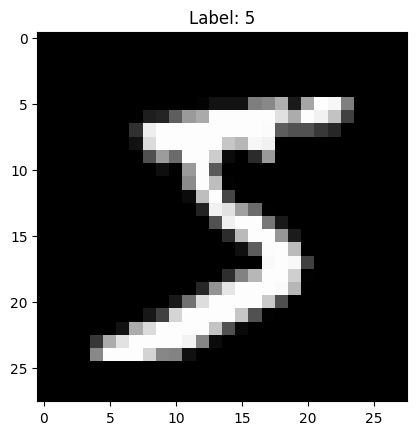

In [4]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# **Data Preprocessing**

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print(X_train.shape)

(60000, 28, 28, 1)


# **CNN Model**

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compile Model**

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **Train Model**

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.9523 - loss: 0.1528 - val_accuracy: 0.9803 - val_loss: 0.0662
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9851 - loss: 0.0470 - val_accuracy: 0.9857 - val_loss: 0.0475
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9895 - loss: 0.0324 - val_accuracy: 0.9879 - val_loss: 0.0461
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9928 - loss: 0.0226 - val_accuracy: 0.9852 - val_loss: 0.0515
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9937 - loss: 0.0184 - val_accuracy: 0.9864 - val_loss: 0.0484


# **Evaluate Model**

In [10]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9878 - loss: 0.0373
Accuracy: 0.9878000020980835


# **Save Model**

In [11]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/digit_model.keras")

print("Model Saved")

Model Saved


In [12]:
import os

print(os.listdir("models"))

['digit_model.keras']


# **Test Prediction**

In [14]:
import numpy as np

image = X_test[0]

prediction = model.predict(
    image.reshape(1,28,28,1)
)

predicted_digit = np.argmax(prediction)

print("Predicted:", predicted_digit)
print("Actual:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted: 7
Actual: 7


# **Accuracy Graph**

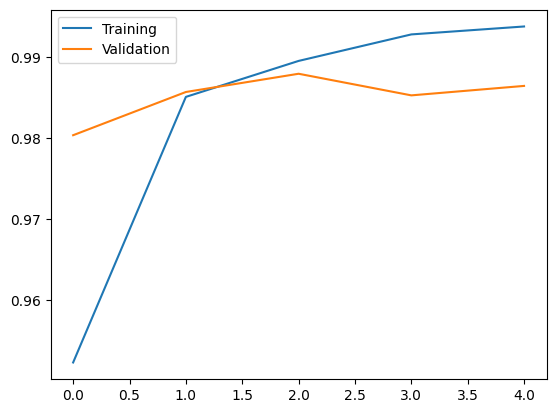

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend([
    'Training',
    'Validation'
])

plt.show()

In [16]:
from google.colab import files

files.download(
    "models/digit_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>